In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC 
from sklearn.preprocessing import StandardScaler


In [22]:
df=pd.read_csv('sensor_raw.csv')

In [23]:
df.head()

,Target(Class),GyroX,GyroY,GyroZ,AccX,AccY,AccZ
0,1,-0.923664,3.694656,0.824427,0.162598,-0.086670,-0.969482
1,1,-0.908397,4.534351,0.832061,0.175781,-0.100586,-1.013184
2,1,0.786260,3.969466,0.587786,0.322754,-0.140381,-0.911621
3,1,0.335878,4.564885,-0.251908,0.480225,-0.226807,-0.936768
4,1,3.351145,2.694656,-0.106870,0.426025,-0.253906,-0.950195


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Target(Class)  1114 non-null   int64  
 1   GyroX          1114 non-null   float64
 2   GyroY          1114 non-null   float64
 3   GyroZ          1114 non-null   float64
 4   AccX           1114 non-null   float64
 5   AccY           1114 non-null   float64
 6   AccZ           1114 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 61.1 KB


In [25]:
# 1. Separamos las características (sensores) de la etiqueta (clase)
X = df.drop('Target(Class)', axis=1)#aqui separamos las caracteristica por quee es lo que se va a predecir
y = df['Target(Class)']

In [26]:
# 2. Dividimos para entrenamiento y prueba (80% entrena, 20% se guarda para el examen)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Set de entrenamiento: {X_train.shape[0]} muestras")
print(f"Set de prueba: {X_test.shape[0]} muestras")

Set de entrenamiento: 891 muestras
Set de prueba: 223 muestras


In [27]:
from sklearn.preprocessing import StandardScaler

# Creamos el escalador
scaler = StandardScaler()

# Ajustamos y transformamos los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformamos los datos de prueba (usando el mismo ajuste que en entrenamiento)
X_test_scaled = scaler.transform(X_test)

print("Datos normalizados. Ahora todos los sensores tienen el mismo peso para la IA.")

Datos normalizados. Ahora todos los sensores tienen el mismo peso para la IA.


In [28]:


# Probemos con parámetros más potentes
# C=100 hace que el modelo penalice más los errores
# gamma=0.1 ayuda a que las fronteras de decisión sean más precisas
modelo_conduccion = SVC(kernel='rbf', C=100, gamma=0.1)

# Entrenamos de nuevo
modelo_conduccion.fit(X_train_scaled, y_train)

# Sacamos las nuevas predicciones
y_pred_nuevo = modelo_conduccion.predict(X_test_scaled)

# Mostramos el nuevo reporte para comparar
print("--- Reporte Mejorado ---")
print(classification_report(y_test, y_pred_nuevo))

--- Reporte Mejorado ---
              precision    recall  f1-score   support

           1       0.54      0.58      0.56        50
           2       0.66      0.57      0.61        58
           3       0.63      0.70      0.66        70
           4       0.83      0.76      0.79        45

    accuracy                           0.65       223
   macro avg       0.66      0.65      0.66       223
weighted avg       0.66      0.65      0.65       223



In [29]:
# Generamos las predicciones del modelo
y_pred = modelo_conduccion.predict(X_test_scaled)

# Mostramos el reporte de métricas (Precisión, Recall, F1)
from sklearn.metrics import classification_report
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           1       0.54      0.58      0.56        50
           2       0.66      0.57      0.61        58
           3       0.63      0.70      0.66        70
           4       0.83      0.76      0.79        45

    accuracy                           0.65       223
   macro avg       0.66      0.65      0.66       223
weighted avg       0.66      0.65      0.65       223



In [30]:
df['Acc_Mag'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

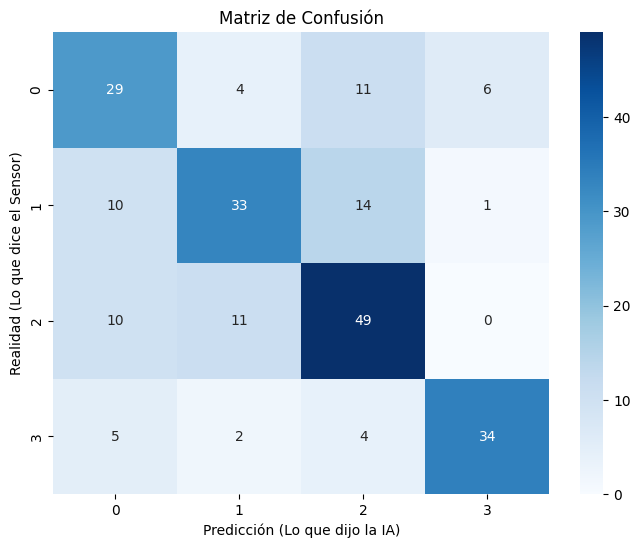

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos la matriz
cm = confusion_matrix(y_test, y_pred)

# La dibujamos para que sea fácil de leer
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción (Lo que dijo la IA)')
plt.ylabel('Realidad (Lo que dice el Sensor)')
plt.title('Matriz de Confusión')
plt.show()

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Creamos el modelo
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenamos con los datos SIN escalar (RF no lo necesita, pero funciona igual)
modelo_rf.fit(X_train, y_train)

# Evaluamos
y_pred_rf = modelo_rf.predict(X_test)
print("--- Comparativa: Random Forest ---")
print(classification_report(y_test, y_pred_rf))



--- Comparativa: Random Forest ---
              precision    recall  f1-score   support

           1       0.67      0.52      0.58        50
           2       0.69      0.62      0.65        58
           3       0.61      0.81      0.70        70
           4       0.87      0.76      0.81        45

    accuracy                           0.69       223
   macro avg       0.71      0.68      0.69       223
weighted avg       0.70      0.69      0.68       223



In [33]:
# 1. Separar las nuevas características suavizadas
X_suavizado = df_suavizado.drop('Target(Class)', axis=1)
y_suavizado = df_suavizado['Target(Class)']

# 2. Nueva división de datos
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_suavizado, y_suavizado, test_size=0.2, random_state=42, stratify=y_suavizado
)

# 3. Entrenar el modelo ganador
modelo_final = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_final.fit(X_train_s, y_train_s)

# 4. Evaluación final
y_pred_final = modelo_final.predict(X_test_s)
print(classification_report(y_test_s, y_pred_final))

NameError: name 'df_suavizado' is not defined

In [ ]:


# 1. Ingeniería de características (Promedio + Desviación Estándar)
df_final = df.copy()
df_final['Acc_Mag'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

sensores = ['GyroX', 'GyroY', 'GyroZ', 'AccX', 'AccY', 'AccZ', 'Acc_Mag']
for s in sensores:
    df_final[f'{s}_mean'] = df_final[s].rolling(window=10).mean()
    df_final[f'{s}_std'] = df_final[s].rolling(window=10).std()

df_final.dropna(inplace=True)

# 2. Preparar datos
X = df_final.drop('Target(Class)', axis=1)
y = df_final['Target(Class)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Modelo robusto (200 árboles para mayor estabilidad)
modelo_final = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_final.fit(X_train, y_train)

# 4. Resultados
y_pred = modelo_final.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.98      0.92      0.95        49
           2       1.00      0.95      0.97        57
           3       0.92      1.00      0.96        70
           4       1.00      1.00      1.00        45

    accuracy                           0.97       221
   macro avg       0.97      0.97      0.97       221
weighted avg       0.97      0.97      0.97       221



In [ ]:
# Extraer la importancia de las características
importancias = modelo_final.feature_importances_
nombres_columnas = X.columns
df_importancia = pd.DataFrame({'Sensor': nombres_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia, x='Importancia', y='Sensor', palette='viridis')
plt.title('Top 10 Características que definen la Conducción')
plt.show()

In [ ]:


# Guardamos el modelo ganador
joblib.dump(modelo_final, 'modelo_conduccion_97.pkl')
print("Modelo exportado como 'modelo_conduccion_97.pkl'")